# 02 - Analisis Exploratorio de Datos (EDA)

**TP2 - Modulo 2 - Clasificacion `smoking`**

Antes de modelar exploramos los datos para entender que tenemos. Trabajamos sobre el CSV generado en el notebook 01. Las figuras se guardan en `imgs/`.

Aclaracion importante: las variables de laboratorio de este dataset no estan en sus unidades clinicas reales (mg/dL, etc.) sino normalizadas de alguna manera. Por eso no interpretamos los valores absolutos, sino las relaciones entre variables y con el target.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import utils
from utils import DATA_PROCESSED, IMGS, TARGET

sns.set_theme(style='whitegrid')
IMGS.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PROCESSED / 'train_clean.csv')
print(df.shape)

(50000, 35)


## Distribucion de la variable objetivo

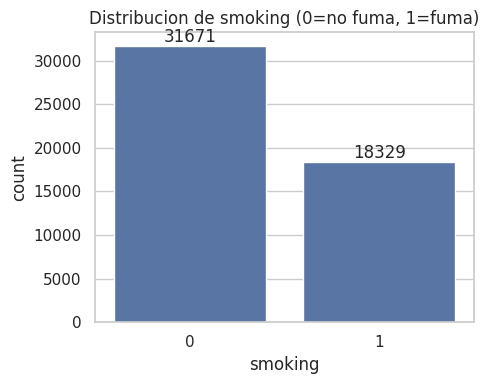

In [2]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x=TARGET, data=df, ax=ax)
ax.set_title('Distribucion de smoking (0=no fuma, 1=fuma)')
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
fig.tight_layout()
fig.savefig(IMGS / 'dist_target.png', dpi=120)
plt.show()

## Distribuciones de variables numericas

Miramos la forma de cada variable. Las de laboratorio como `triglyceride`, `gtp` o `alt` tienen valores extremos muy altos.

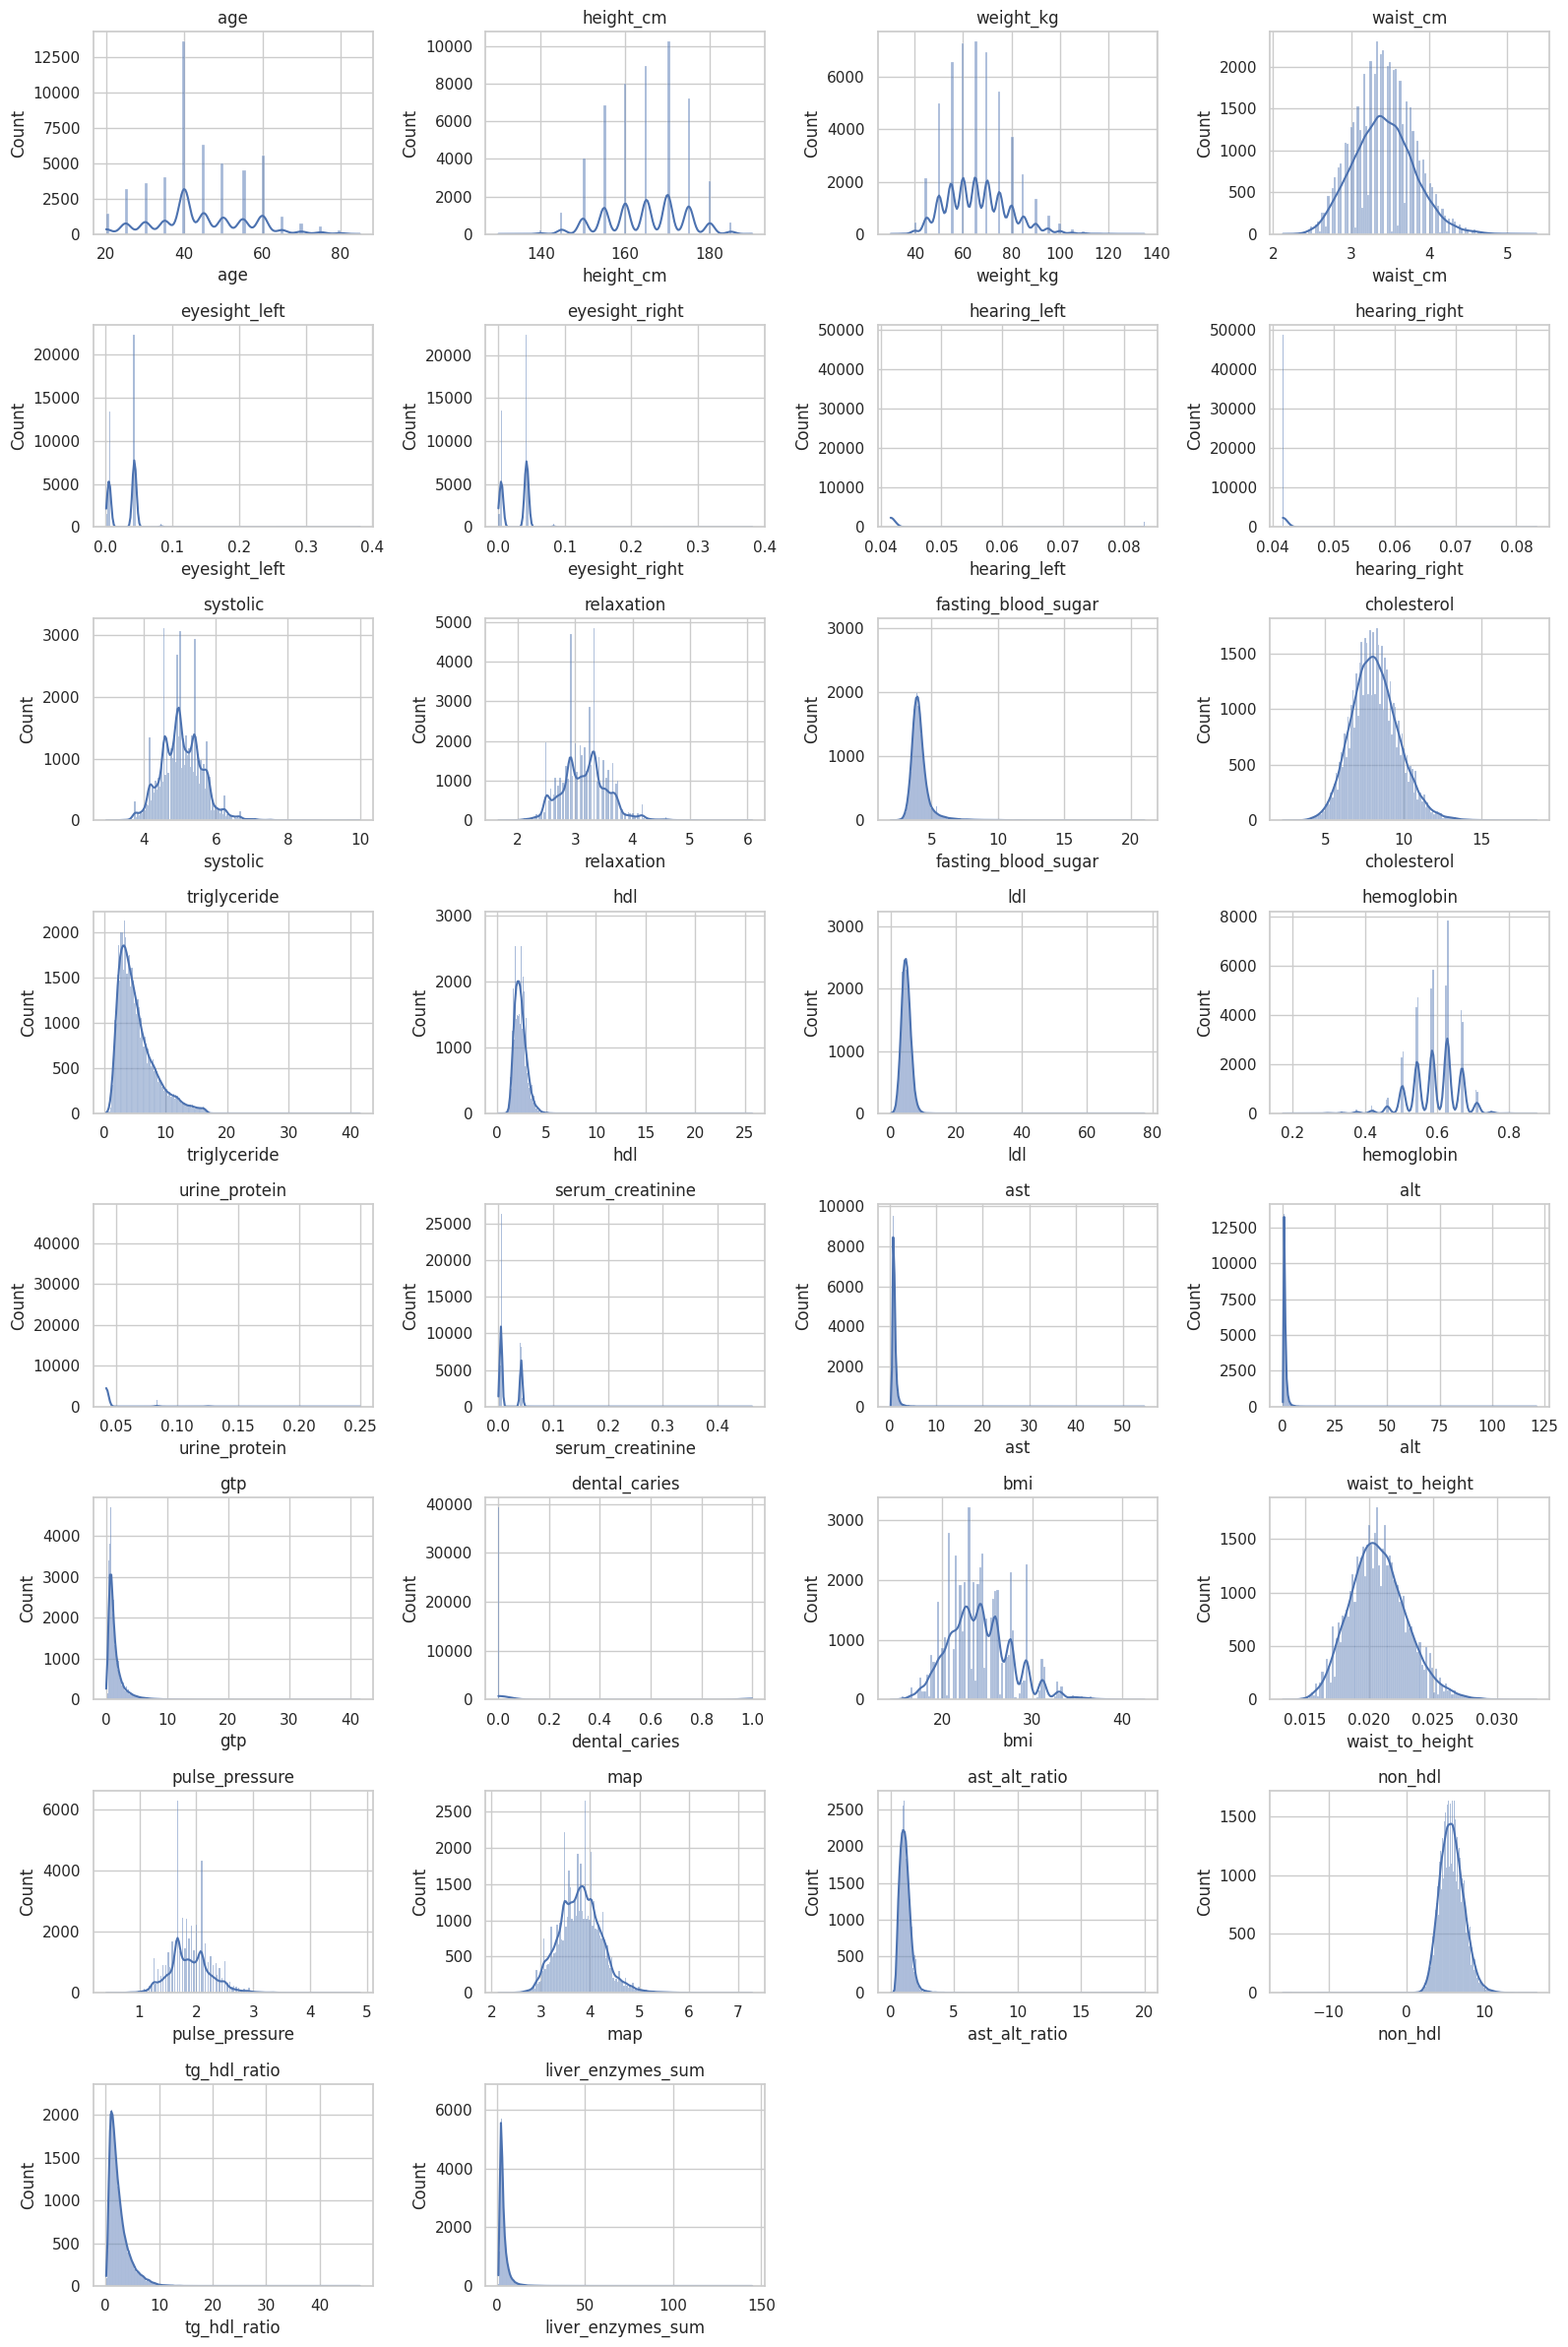

In [3]:
num_cols = df.select_dtypes(include=np.number).columns.drop([TARGET], errors='ignore')
num_cols = [c for c in num_cols if c != 'id']

n = len(num_cols)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
for ax in axes.ravel()[n:]:
    ax.axis('off')
fig.tight_layout()
fig.savefig(IMGS / 'hist_numericas.png', dpi=110)
plt.show()

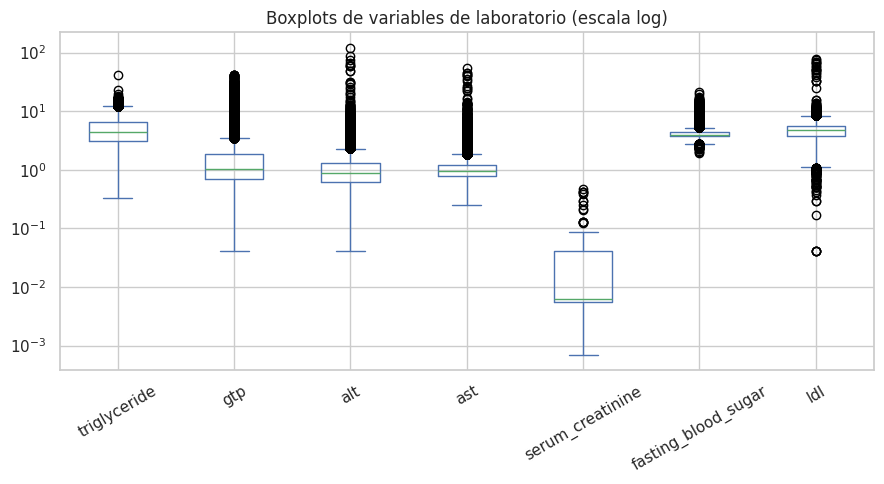

In [4]:
labs = [c for c in ['triglyceride', 'gtp', 'alt', 'ast', 'serum_creatinine',
                     'fasting_blood_sugar', 'ldl'] if c in df.columns]
fig, ax = plt.subplots(figsize=(9, 5))
df[labs].plot(kind='box', ax=ax, vert=True)
ax.set_yscale('log')
ax.set_title('Boxplots de variables de laboratorio (escala log)')
plt.xticks(rotation=30)
fig.tight_layout()
fig.savefig(IMGS / 'boxplots_labs.png', dpi=120)
plt.show()

## Relaciones exploratorias entre variables y target

`smoking` es una variable binaria (0/1). Por eso **no usamos el coeficiente de correlacion de Pearson entre variables continuas y el target para sacar conclusiones**: puede ser tentador ordenar variables por ese numero, pero no es la forma adecuada de interpretar una relacion continua vs binaria.

La matriz siguiente se usa solamente para mirar correlaciones **entre predictores numericos** (posible redundancia/multicolinealidad). Para el target usamos comparaciones descriptivas por clase: distribuciones, medianas y tasas.


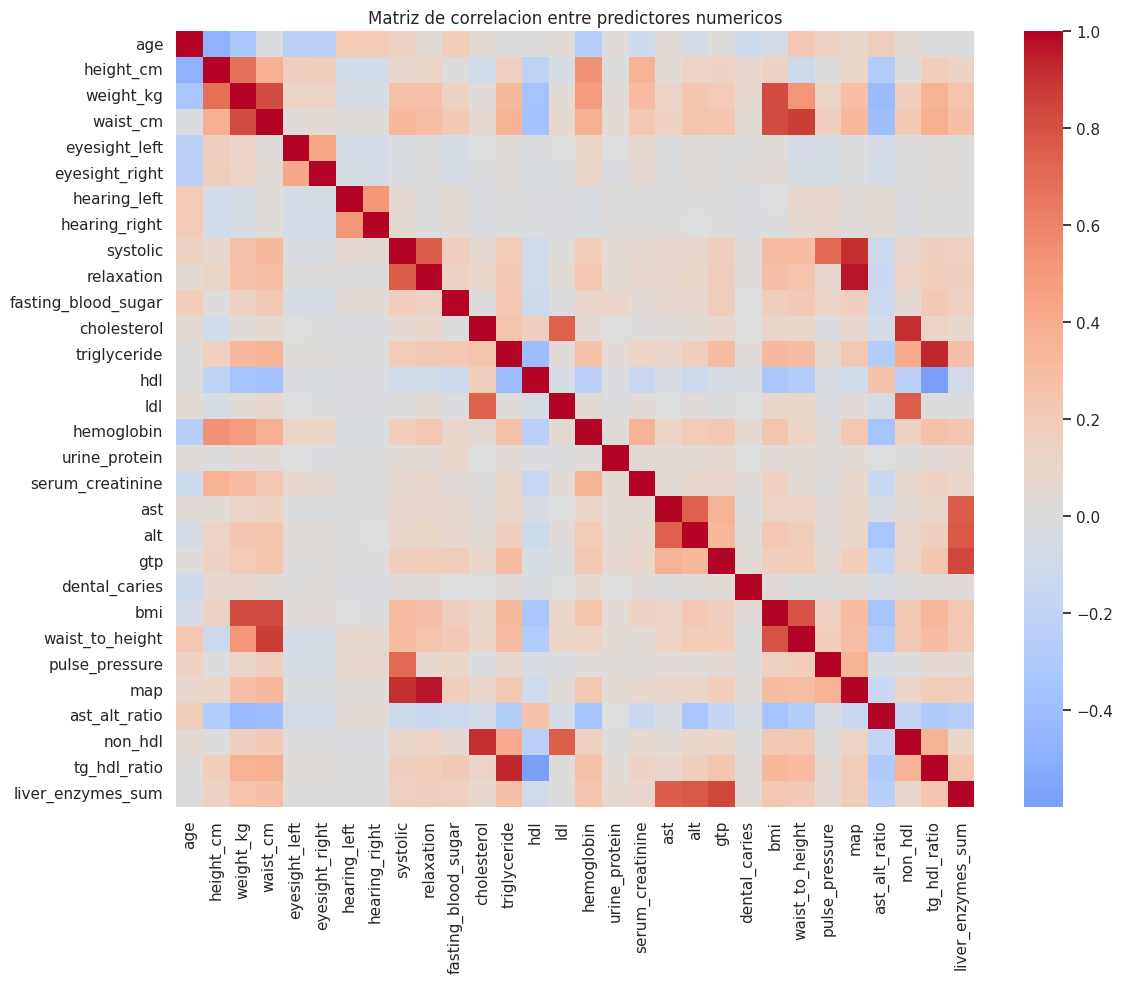

Resumen descriptivo por clase (no es correlacion):


hemoglobin          gtp       triglyceride       height_cm          \
            median  mean median  mean       median  mean    median    mean   
smoking                                                                      
0             0.58  0.57   0.88  1.29          4.0  4.71     160.0  161.88   
1             0.63  0.63   1.54  2.32          5.5  6.26     170.0  169.45   

        weight_kg         
           median   mean  
smoking                   
0            60.0  62.94  
1            70.0  70.96

In [5]:
# Matriz de correlacion solo entre predictores numericos.
# No incluye el target binario `smoking`.
corr_predictores = df[list(num_cols)].corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_predictores, annot=False, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Matriz de correlacion entre predictores numericos')
fig.tight_layout()
fig.savefig(IMGS / 'corr_heatmap.png', dpi=120)
plt.show()

# Para variables continuas vs target binario miramos diferencias descriptivas por clase.
variables_interes = [c for c in ['hemoglobin', 'gtp', 'triglyceride', 'height_cm', 'weight_kg']
                     if c in df.columns]
resumen_clase = (
    df.groupby(TARGET)[variables_interes]
      .agg(['median', 'mean'])
      .round(2)
)
print('Resumen descriptivo por clase (no es correlacion):')
display(resumen_clase)


## Categoricas vs target

Para las variables categoricas miramos directamente la tasa de fumadores en cada grupo.

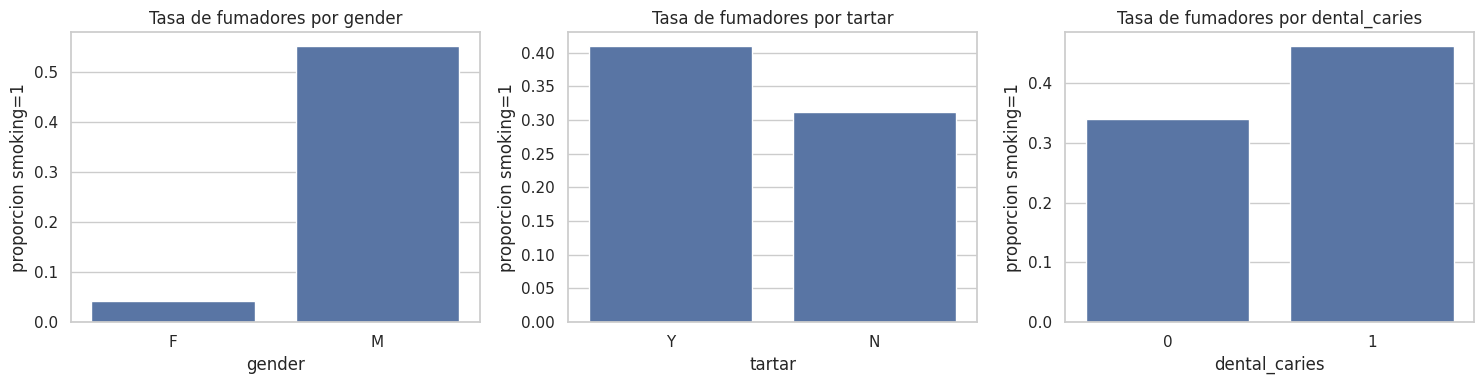

In [6]:
cat_cols = [c for c in ['gender', 'tartar', 'dental_caries'] if c in df.columns]
fig, axes = plt.subplots(1, len(cat_cols), figsize=(5*len(cat_cols), 4))
axes = np.atleast_1d(axes)
for ax, col in zip(axes, cat_cols):
    sns.barplot(x=col, y=TARGET, data=df, ax=ax, errorbar=None)
    ax.set_title(f'Tasa de fumadores por {col}')
    ax.set_ylabel('proporcion smoking=1')
fig.tight_layout()
fig.savefig(IMGS / 'bivariado_categoricas.png', dpi=120)
plt.show()

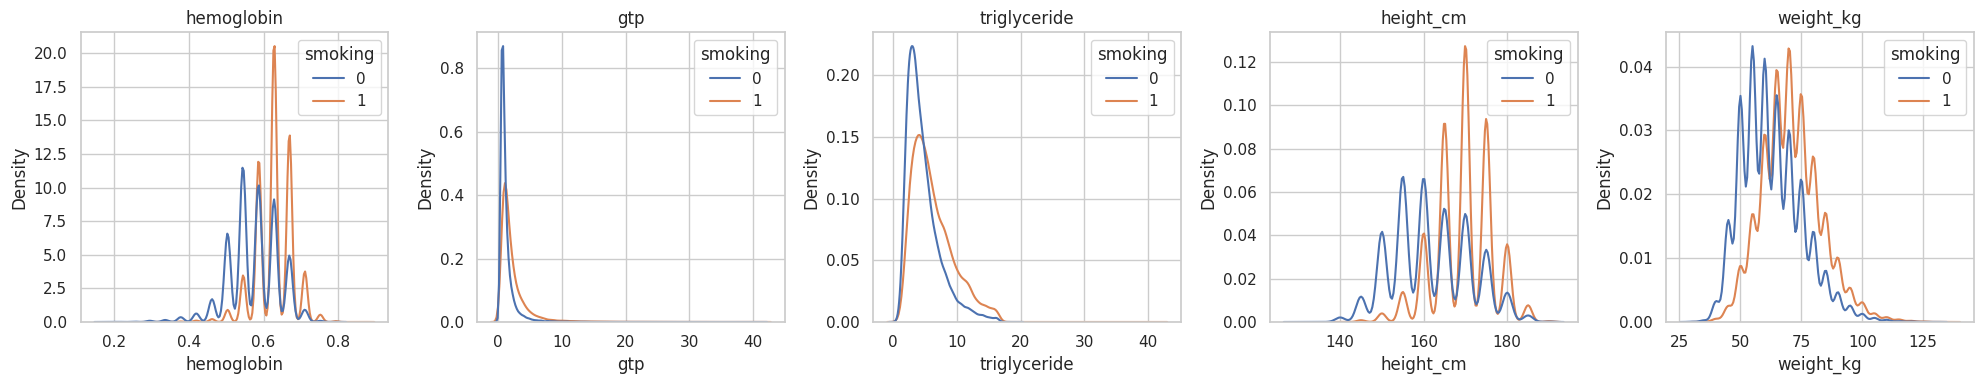

In [7]:
# Distribuciones de variables continuas segun clase del target.
# Estos graficos sirven para detectar seniales exploratorias, no para afirmar causalidad.
variables_interes = [c for c in ['hemoglobin', 'gtp', 'triglyceride', 'height_cm', 'weight_kg']
                     if c in df.columns]
fig, axes = plt.subplots(1, len(variables_interes), figsize=(4*len(variables_interes), 4))
axes = np.atleast_1d(axes)
for ax, col in zip(axes, variables_interes):
    sns.kdeplot(data=df, x=col, hue=TARGET, common_norm=False, ax=ax)
    ax.set_title(col)
fig.tight_layout()
fig.savefig(IMGS / 'kde_predictores.png', dpi=120)
plt.show()


## Conclusion del EDA

- El target esta desbalanceado de forma moderada: hay mas no fumadores que fumadores. Por eso la metrica principal del TP es F1 para la clase 1 y no accuracy sola.
- No sacamos conclusiones desde una correlacion Pearson entre variables continuas y `smoking`, porque `smoking` es binaria. En su lugar usamos comparaciones descriptivas por clase y graficos de distribucion como seniales exploratorias.
- En los graficos por clase se observan diferencias descriptivas en `hemoglobin`, `gtp`, `triglyceride`, `height_cm`, `weight_kg` y en la tasa por `gender`. Esas diferencias sugieren variables candidatas, pero la evidencia predictiva se valida despues con el modelo y sus metricas.
- Las variables de laboratorio tienen bastantes valores extremos pero no los vamos a eliminar: XGBoost los maneja bien y ademas no podriamos hacer lo mismo en el set de prediccion sin una regla robusta definida solo con train.
- `oral` y `hearing_*` confirman lo que vimos en el notebook 01: aportan poca o ninguna variacion util.
